In [ ]:
## importing libraries
import torch
import torch.nn as nn
from torch.optim import Adam
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Dataset , DataLoader
import numpy as np
from PIL import Image 
import os 

In [ ]:
path_train_sample = "/kaggle/input/datasets/oxcdcd/cifar10/cifar10/train"
## contains 10 classes

In [ ]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize( # scaling -1 to 1
        mean = (0.5,0.5,0.5),
        std = (0.5,0.5,0.5)
    )
])

In [ ]:
from torchvision.datasets import ImageFolder
## the dataset files are arranged according to standard file format required for ImageFolder 
cifar_dataset = ImageFolder(root=path_train_sample, transform=transforms)
cifar_loader = DataLoader(
    dataset=cifar_dataset, 
    batch_size=128, 
    shuffle=True, 
    num_workers=2
)

In [ ]:
for x,y in cifar_loader:
    break 

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, half_batch):
        super().__init__()
        self.half_batch = half_batch

        self.discriminator = nn.Sequential(
            # Input: (batch_size, 3, 32, 32)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1), # -> (batch_size, 32, 16, 16)
            nn.BatchNorm2d(num_features=32),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1), # -> (batch_size, 64, 8, 8)
            nn.BatchNorm2d(num_features=64),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1), # -> (batch_size, 128, 4, 4)
            nn.BatchNorm2d(num_features=128),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1), # -> (batch_size, 256, 2, 2)
            nn.BatchNorm2d(num_features=256),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Flatten(), # Flattens to: batch_size, (256 * 2 * 2) = 1024
            nn.Linear(in_features=256 * 2 * 2, out_features=1), # Exactly 1024 input features
            nn.Sigmoid()
        )

    def generate_real_sample(self,train_dataset:Dataset):
      x = []
      for i in range(self.half_batch):
        rand_idx = np.random.randint(0,len(train_dataset)-1)
        image,_ = train_dataset[rand_idx]
        x.append(image)
      x = torch.stack(x)
      y = torch.ones((self.half_batch,1))
      return x,y

    def generate_fake_sample(self):
        # Correct 4D shape: (batch_size, channels, height, width)
        x = torch.rand(self.half_batch, 3, 32, 32)
        # Match labels to the actual batch size dimension
        y = torch.zeros((self.half_batch, 1))
        return x, y

    def forward(self, X):
        """ Match case: Change internal 'x' variable to track input parameter 'X' it cal take real as well as fake """
        y = self.discriminator(X)
        return y


In [ ]:
from torch.nn.modules.activation import LeakyReLU
class Generator(nn.Module):
  def __init__(self,latent_dim,half_batch):
    super().__init__()
    self.n_nodes = 4*4*256
    self.half_batch = half_batch
    self.latent_dim = latent_dim
    self.fc = nn.Linear(in_features=latent_dim,out_features=self.n_nodes)
    self.upscaling = nn.Sequential(
       nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,8,8)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,16,16)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=4, stride=2, padding=1), ## (128,32,32)
       nn.LeakyReLU(0.2),
       nn.ConvTranspose2d(in_channels=128, out_channels=3, kernel_size=3,padding=1), # (3,32,32)
       nn.Tanh()
    )
  def generate_latent_sample(self):
    samples = torch.rand(self.latent_dim*self.half_batch)
    samples = samples.reshape((self.half_batch,self.latent_dim))
    return samples
  def forward(self,z):
    """ here we get latent dim (100 vector) as input and generate 32,32,3 image """
    x = self.fc(z)
    x = x.reshape(-1,256,4,4) # (batch_size,256,4,4)
    z = self.upscaling(x)
    return z # (3,32,32) # image

In [ ]:
latent_dim = 100
batch_size = 128
half_batch = int(batch_size / 2)
batch_per_epoch = int(len(cifar_dataset) / batch_size)
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 100

In [ ]:
model_g = Generator(latent_dim = latent_dim,half_batch=half_batch).to(device)
lr = 0.0002
model_d = Discriminator(half_batch = half_batch).to(device)
optim_d = Adam(model_d.parameters(),lr=lr, betas=(0.5, 0.999))
optim_g = Adam(model_g.parameters(),lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
## training loop 
for epoch in range(num_epochs):
    for i in range(batch_per_epoch): ## batches per epoch
        ## training discriminator 
        optim_d.zero_grad()
        X_real,y_real = model_d.generate_real_sample(cifar_dataset)
        X_real, y_real = X_real.to(device), y_real.to(device)
        y_pred_real = model_d(X_real)
        loss_real = criterion(y_pred_real,y_real)

        z_sample = model_g.generate_latent_sample().to(device) # return the 100th dim 64 vectors
        X_fake = model_g(z_sample).detach()
        y_fake = torch.zeros((half_batch,1)).to(device)
        y_pred_fake = model_d(X_fake)
        loss_fake = criterion(y_pred_fake,y_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        optim_d.step()

        ## training generator
        optim_g.zero_grad()
        z_sample = model_g.generate_latent_sample().to(device)
        X_fake = model_g(z_sample)
        y_fake = torch.ones((half_batch,1)).to(device) ## tries to check weather discriminator will fool 
        y_pred = model_d(X_fake)
        loss_fake = criterion(y_pred,y_fake)
        loss_fake.backward()
        optim_g.step()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {loss_d.item():.4f} | Loss G: {loss_fake.item():.4f}")

## done 

Epoch [1/100] | Loss D: 0.0760 | Loss G: 4.6389
Epoch [2/100] | Loss D: 0.0240 | Loss G: 5.4783
Epoch [3/100] | Loss D: 0.0394 | Loss G: 5.6919
Epoch [4/100] | Loss D: 0.1501 | Loss G: 4.9762
Epoch [5/100] | Loss D: 0.0080 | Loss G: 5.9480
Epoch [6/100] | Loss D: 0.2063 | Loss G: 5.8023
Epoch [7/100] | Loss D: 0.7547 | Loss G: 2.7573
Epoch [8/100] | Loss D: 0.9603 | Loss G: 1.8792
Epoch [9/100] | Loss D: 0.8935 | Loss G: 2.8184
Epoch [10/100] | Loss D: 1.0780 | Loss G: 2.9652
Epoch [11/100] | Loss D: 0.9044 | Loss G: 2.3418
Epoch [12/100] | Loss D: 0.8857 | Loss G: 2.2846
Epoch [13/100] | Loss D: 0.4449 | Loss G: 2.1941
Epoch [14/100] | Loss D: 1.0248 | Loss G: 1.6577
Epoch [15/100] | Loss D: 0.9328 | Loss G: 1.9443
Epoch [16/100] | Loss D: 0.8255 | Loss G: 2.4139
Epoch [17/100] | Loss D: 0.8041 | Loss G: 2.3526
Epoch [18/100] | Loss D: 1.0722 | Loss G: 2.1401
Epoch [19/100] | Loss D: 1.0449 | Loss G: 1.7655
Epoch [20/100] | Loss D: 1.1502 | Loss G: 1.6284
Epoch [21/100] | Loss D: 1.0194 | Loss G: 2.0210
Epoch [22/100] | Loss D: 1.1181 | Loss G: 1.4698
Epoch [23/100] | Loss D: 0.6897 | Loss G: 2.9268
Epoch [24/100] | Loss D: 1.1939 | Loss G: 1.7088
Epoch [25/100] | Loss D: 0.7883 | Loss G: 1.9396
Epoch [26/100] | Loss D: 0.8717 | Loss G: 2.7191
Epoch [27/100] | Loss D: 0.7769 | Loss G: 2.2903
Epoch [28/100] | Loss D: 0.8543 | Loss G: 3.4596
Epoch [29/100] | Loss D: 0.7491 | Loss G: 2.3241
Epoch [30/100] | Loss D: 0.6349 | Loss G: 1.8817
Epoch [31/100] | Loss D: 0.7809 | Loss G: 2.0325
Epoch [32/100] | Loss D: 0.5484 | Loss G: 2.7317
Epoch [33/100] | Loss D: 0.6667 | Loss G: 2.1185
Epoch [34/100] | Loss D: 1.2785 | Loss G: 2.0357
Epoch [35/100] | Loss D: 1.6795 | Loss G: 1.1320
Epoch [36/100] | Loss D: 1.0809 | Loss G: 2.0731
Epoch [37/100] | Loss D: 0.3721 | Loss G: 1.5165
Epoch [38/100] | Loss D: 0.6811 | Loss G: 1.9783
Epoch [39/100] | Loss D: 0.3758 | Loss G: 2.3331
Epoch [40/100] | Loss D: 0.4965 | Loss G: 1.5521
Epoch [41/100] | Loss D: 0.4994 | Loss G: 2.8853
Epoch [42/100] | Loss D: 0.4612 | Loss G: 2.1069
Epoch [43/100] | Loss D: 0.7389 | Loss G: 2.1684
Epoch [44/100] | Loss D: 0.6279 | Loss G: 2.2970
Epoch [45/100] | Loss D: 0.8619 | Loss G: 2.2178
Epoch [46/100] | Loss D: 0.4168 | Loss G: 3.3649
Epoch [47/100] | Loss D: 0.9190 | Loss G: 2.0583
Epoch [48/100] | Loss D: 0.8837 | Loss G: 3.8283
Epoch [49/100] | Loss D: 1.3178 | Loss G: 3.9807
Epoch [50/100] | Loss D: 0.8609 | Loss G: 2.6200
Epoch [51/100] | Loss D: 0.6576 | Loss G: 2.5533
Epoch [52/100] | Loss D: 0.9564 | Loss G: 2.8795
Epoch [53/100] | Loss D: 0.3493 | Loss G: 2.0386
Epoch [54/100] | Loss D: 0.4256 | Loss G: 2.4817
Epoch [55/100] | Loss D: 1.1336 | Loss G: 1.2179
Epoch [56/100] | Loss D: 0.4717 | Loss G: 3.4680
Epoch [57/100] | Loss D: 0.3464 | Loss G: 1.9780
Epoch [58/100] | Loss D: 0.3837 | Loss G: 2.7101
Epoch [59/100] | Loss D: 0.7045 | Loss G: 1.9827
Epoch [60/100] | Loss D: 0.3320 | Loss G: 1.8396
Epoch [61/100] | Loss D: 0.2809 | Loss G: 2.0579
Epoch [62/100] | Loss D: 0.8233 | Loss G: 3.0644
Epoch [63/100] | Loss D: 0.5154 | Loss G: 2.2158
Epoch [64/100] | Loss D: 1.0374 | Loss G: 2.2399
Epoch [65/100] | Loss D: 0.5565 | Loss G: 2.8241
Epoch [66/100] | Loss D: 0.5899 | Loss G: 1.8412
Epoch [67/100] | Loss D: 0.8165 | Loss G: 2.1537
Epoch [68/100] | Loss D: 0.6319 | Loss G: 2.7005
Epoch [69/100] | Loss D: 0.3096 | Loss G: 2.3756
Epoch [70/100] | Loss D: 0.3090 | Loss G: 2.8769
Epoch [71/100] | Loss D: 0.5182 | Loss G: 2.8175
Epoch [72/100] | Loss D: 0.2230 | Loss G: 4.7302
Epoch [73/100] | Loss D: 0.5296 | Loss G: 1.9776
Epoch [74/100] | Loss D: 0.3101 | Loss G: 4.6926
Epoch [75/100] | Loss D: 0.7693 | Loss G: 2.5638
Epoch [76/100] | Loss D: 0.5969 | Loss G: 1.9854
Epoch [77/100] | Loss D: 0.4424 | Loss G: 2.2203
Epoch [78/100] | Loss D: 1.1426 | Loss G: 1.6586
Epoch [79/100] | Loss D: 1.0467 | Loss G: 3.7701
Epoch [80/100] | Loss D: 0.4513 | Loss G: 2.9813
Epoch [81/100] | Loss D: 0.7414 | Loss G: 3.3722
Epoch [82/100] | Loss D: 0.6867 | Loss G: 1.4898
Epoch [83/100] | Loss D: 0.2854 | Loss G: 1.5324
Epoch [84/100] | Loss D: 0.8446 | Loss G: 2.9951
Epoch [85/100] | Loss D: 1.3687 | Loss G: 2.4964
Epoch [86/100] | Loss D: 0.6779 | Loss G: 2.7653
Epoch [87/100] | Loss D: 0.6838 | Loss G: 3.0388
Epoch [88/100] | Loss D: 0.2352 | Loss G: 2.4815
Epoch [89/100] | Loss D: 0.4647 | Loss G: 1.9567
Epoch [90/100] | Loss D: 0.7432 | Loss G: 1.0640
Epoch [91/100] | Loss D: 0.3899 | Loss G: 3.0534
Epoch [92/100] | Loss D: 0.3410 | Loss G: 2.5440
Epoch [93/100] | Loss D: 0.6673 | Loss G: 2.9851
Epoch [94/100] | Loss D: 0.8645 | Loss G: 3.3827
Epoch [95/100] | Loss D: 0.3453 | Loss G: 2.5988
Epoch [96/100] | Loss D: 0.5273 | Loss G: 4.0357
Epoch [97/100] | Loss D: 0.4220 | Loss G: 3.6121
Epoch [98/100] | Loss D: 0.6261 | Loss G: 1.8691
Epoch [99/100] | Loss D: 0.3151 | Loss G: 1.5170
Epoch [100/100] | Loss D: 0.3122 | Loss G: 2.9054

In [ ]:
cifar_dataset[0][0].shape

In [ ]:
def pick_random_sample(cifa_dataset):
    rand_index = np.random.randint(0,len(cifar_dataset)-1)
    x = cifar_dataset[rand_index][0].unsqueeze(0)
    return x

In [ ]:
x = pick_random_sample(cifar_dataset)
import matplotlib.pyplot as plt 
plt.subplot(1,2,1)
x = x.squeeze(0).permute(1, 2, 0).numpy()
plt.imshow(x)
plt.title("Original Image")

In [ ]:
import time 
model_g.eval()
i = 10
while(i!=0):
    with torch.inference_mode():
        time.sleep(1)
        original_half_batch = model_g.half_batch
        model_g.half_batch = 1 # only iterating one sample
        z_sample = model_g.generate_latent_sample().to(device)
        model_g.half_batch = original_half_batch
        X_pred = model_g(z_sample)
        X_pred = (X_pred.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2 # denormalizeing from -1to 1 to 0 to1 
        plt.figure(figsize=(4, 4))
        plt.imshow(X_pred)
        plt.title("Generated Image")
        plt.axis("off")
        plt.show()
        i -=1

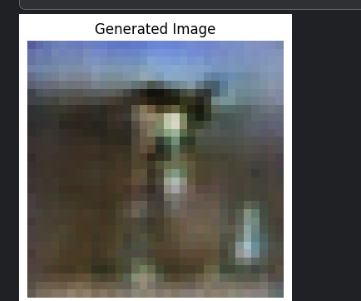

### Let's train for 100 epochs 